## libaray off  import to make project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# load the dataset
data= pd.read_csv("data set/spam.csv",encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [82]:
# measure the missing values
(data.isna().mean()*100).sort_values(ascending=False)

Unnamed: 4    99.892319
Unnamed: 3    99.784637
Unnamed: 2    99.102656
v1             0.000000
v2             0.000000
dtype: float64

In [3]:
# Drop the unnecessary columns
columns_drop=(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
data=data.drop(columns=columns_drop,axis=1)
data.reset_index(drop=True,inplace=True)

In [ ]:
data.duplicated().sum()


403

In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data.rename(columns={'v1': 'Label', 'v2': 'Message'}, inplace=True)


In [87]:
print('dataset shape:',data.shape)

dataset shape: (5169, 2)


In [88]:
data['Label'].value_counts()
#### data inplancing using smote

Label
ham     4516
spam     653
Name: count, dtype: int64

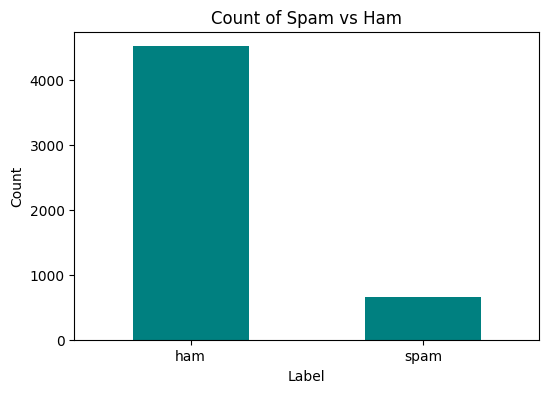

In [89]:
plt.figure(figsize=(6,4)) 
data['Label'].value_counts().plot(kind='bar', color='teal', rot=0) 
plt.title('Count of Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [9]:
# def delete stopword
nltk.download('stopwords') 
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ibrahememam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Clean text of meessage 


In [10]:
# clean the text data and delete the stop words and stem the words
def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text).lower())
    words = text.split()
    clean_words = [ps.stem(w) for w in words if w not in stop_words]
    return ' '.join(clean_words)

In [11]:
# apply function of text data to clean message text
data['Cleaned_Message'] = data['Message'].apply(clean_text)
data.head()

,Label,Message,Cleaned_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [12]:
new_label = {"Label": {"ham": 0, "spam": 1}}
data = data.replace(new_label)

In [13]:
x= data['Cleaned_Message']
y=data['Label']

# Prepossing data 


In [95]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
    )

## Feature Extraction (TF-IDF)

In [96]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    max_df=0.7,
    use_idf=True
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print('X_train_tfidf shape:', x_train_tfidf.shape)
print('X_test_tfidf shape:', x_test_tfidf.shape)

X_train_tfidf shape: (4135, 5000)
X_test_tfidf shape: (1034, 5000)


In [97]:
# handel the imbalanced data using SMOTE
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smote, y_train_smote=smote.fit_resample(x_train_tfidf, y_train)

print('X_train_smote shape:', x_train_smote.shape)
print('y_train_smote shape:', y_train_smote.shape)

X_train_smote shape: (7226, 5000)
y_train_smote shape: (7226,)


In [98]:
y_train_smote.value_counts()

Label
0    3613
1    3613
Name: count, dtype: int64

In [99]:
# Build preprocessing + model pipeline with GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score
import joblib

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, use_idf=True)),
    ('clf', MultinomialNB())
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.7, 0.85],
    'clf__alpha': [0.01, 0.1, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)

best_pipeline = grid.best_estimator_
print('Best pipeline params:', grid.best_params_)

y_train_pred = best_pipeline.predict(x_train)
y_test_pred = best_pipeline.predict(x_test)

print('train report: ', classification_report(y_train, y_train_pred))
print('test report: ', classification_report(y_test, y_test_pred))
print('train score: ', f1_score(y_train, y_train_pred, average='macro'))
print('test score: ', f1_score(y_test, y_test_pred, average='macro'))

joblib.dump(best_pipeline, 'best_spam_pipeline.joblib')


train report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99      3613
           1       0.99      0.99      0.99      3613

    accuracy                           0.99      7226
   macro avg       0.99      0.99      0.99      7226
weighted avg       0.99      0.99      0.99      7226

test report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.91      0.91      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034

train score:  0.9919734286682589
test score:  0.9475539550100175


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_smote)
x_test_poly=poly.transform(x_test_tfidf)

model=LogisticRegression(penalty='l2',solver='liblinear',C=0.9)
model.fit(x_train_poly,y_train_smote)

y_train_pred=model.predict(x_train_poly)
y_test_pred=model.predict(x_test_poly)

print('train report: ',classification_report(y_train_smote,y_train_pred))

print('test report: ',classification_report(y_test,y_test_pred))
print('train score: ',f1_score(y_train_smote,y_train_pred,average='macro'))

print('test score: ',f1_score(y_test,y_test_pred,average='macro'))

train report:                precision    recall  f1-score   support

           0       0.99      1.00      0.99      3613
           1       1.00      0.99      0.99      3613

    accuracy                           0.99      7226
   macro avg       0.99      0.99      0.99      7226
weighted avg       0.99      0.99      0.99      7226

test report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.91      0.91      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034

train score:  0.9943260395134911
test score:  0.9475539550100175


In [101]:
from sklearn.tree import DecisionTreeClassifier
ds=DecisionTreeClassifier(max_depth=50,random_state=42)
ds.fit(x_train_smote,y_train_smote)
y_train_pred=ds.predict(x_train_smote)
y_test_pred=ds.predict(x_test_tfidf)

print('train report: ',classification_report(y_train_smote,y_train_pred))

print('test report: ',classification_report(y_test,y_test_pred))
print('train score: ',f1_score(y_train_smote,y_train_pred,average='macro'))

print('test score: ',f1_score(y_test,y_test_pred,average='macro'))

train report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00      3613
           1       1.00      1.00      1.00      3613

    accuracy                           1.00      7226
   macro avg       1.00      1.00      1.00      7226
weighted avg       1.00      1.00      1.00      7226

test report:                precision    recall  f1-score   support

           0       0.97      0.97      0.97       903
           1       0.78      0.80      0.79       131

    accuracy                           0.95      1034
   macro avg       0.88      0.88      0.88      1034
weighted avg       0.95      0.95      0.95      1034

train score:  0.999861610847059
test score:  0.8809740579118659


In [102]:
from sklearn.ensemble import RandomForestClassifier
ds=RandomForestClassifier(max_depth=50,random_state=2)
ds.fit(x_train_smote,y_train_smote)
y_train_pred=ds.predict(x_train_smote)
y_test_pred=ds.predict(x_test_tfidf)


print('train score: ',f1_score(y_train_smote,y_train_pred,average='macro'))

print('test score: ',f1_score(y_test,y_test_pred,average='macro'))


train score:  0.9968170172959654
test score:  0.9404305134037105


In [103]:
from sklearn.svm import SVC

sv=SVC()
sv.fit(x_train_smote,y_train_smote)
y_train_pred=sv.predict(x_train_smote)
y_test_pred=sv.predict(x_test_tfidf)


print('train score: ',f1_score(y_train_smote,y_train_pred,average='macro'))

print('test score: ',f1_score(y_test,y_test_pred,average='macro'))

train score:  0.999861610847059
test score:  0.9510366987992558


In [ ]:
from sklearn.svm import LinearSVC
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_smote)
x_test_poly=poly.transform(x_test_tfidf)

model=LinearSVC(penalty='l2',C=.9)
model.fit(x_train_poly,y_train_smote)

y_train_pred=model.predict(x_train_poly)
y_test_pred=model.predict(x_test_poly)

print('train report: ',classification_report(y_train_smote,y_train_pred))

print('test report: ',classification_report(y_test,y_test_pred))
print('train score: ',f1_score(y_train_smote,y_train_pred,average='macro'))

print('test score: ',f1_score(y_test,y_test_pred,average='macro'))

/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


train report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00      3613
           1       1.00      1.00      1.00      3613

    accuracy                           1.00      7226
   macro avg       1.00      1.00      1.00      7226
weighted avg       1.00      1.00      1.00      7226

test report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.96      0.92      0.94       131

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034

train score:  0.999861610847059
test score:  0.9643349889624724


In [105]:
from sklearn.naive_bayes import MultinomialNB
niv = MultinomialNB()
niv.fit(x_train_smote, y_train_smote)
y_train_pred = niv.predict(x_train_smote)
y_test_pred = niv.predict(x_test_tfidf)

print('train score: ', f1_score(y_train_smote, y_train_pred, average='macro'))
print('test score: ', f1_score(y_test, y_test_pred, average='macro'))


train score:  0.9869913391525827
test score:  0.9372816381987578


In [48]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly_svc = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('svc', LinearSVC(penalty='l2',C=.9))
])

In [78]:
models = [
    ('Polynomial SVM',
         poly_svc),
    ('Logistic Regression',
     LogisticRegression(max_iter=1000, random_state=42)),

    ('Decision Tree',
     DecisionTreeClassifier(max_depth=20, random_state=42)),

    ('Random Forest',
     RandomForestClassifier(n_estimators=200, random_state=42)),

    ('Linear SVC',
     LinearSVC(C=1.0)),

    ('Naive Bayes',
     MultinomialNB()),

    ('XGBoost',
     XGBClassifier(
         n_estimators=200,
         max_depth=6,
         learning_rate=0.1,
         random_state=42,
         eval_metric='logloss'
     ))
]

In [76]:
from sklearn.model_selection import cross_validate

for name, model in models:

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
               max_features=5000,
               ngram_range=(1, 2),
               max_df=0.7,
               use_idf=True
        )),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        x,
        y,
        cv=5,
        scoring='f1',
        return_train_score=True,
        n_jobs=-1
    )

    print("="*50)
    print(name)
    print("Train F1:", scores['train_score'].mean())
    print("Test F1 :", scores['test_score'].mean())

/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.l

Polynomial SVM
Train F1: 0.9943757324069576
Test F1 : 0.9255208591302516
Logistic Regression
Train F1: 0.9621758128129659
Test F1 : 0.9100842926982466
Decision Tree
Train F1: 0.968510703890424
Test F1 : 0.8131220548949726
Random Forest
Train F1: 0.99942510333185
Test F1 : 0.9042994509150641


/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.l

Linear SVC
Train F1: 0.9967569886061508
Test F1 : 0.9298768511278809
Naive Bayes
Train F1: 0.9353064600956863
Test F1 : 0.8888040796836748
XGBoost
Train F1: 0.9677136498972134
Test F1 : 0.8763969644542856


In [67]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
               max_features=5000,
               ngram_range=(1, 2),
               max_df=0.7,
               use_idf=True
    )),
    ('poly', PolynomialFeatures()),
    ('model', LinearSVC(max_iter=10000))
])

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'poly__degree': [2, 3],
    'model__C': [0.01, 0.1, .9,],
    'model__penalty': ['l1', 'l2'],

}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid.fit(x, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ibrahememam/.l

[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=2; total time=   0.2s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=2; total time=   0.2s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=2; total time=   0.3s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=2; total time=   0.3s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=2; total time=   0.4s


/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=3; total time=   0.6s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=3; total time=   0.7s
[CV] END ...model__C=0.01, model__penalty=l1, poly__degree=3; total time=   0.7s


...

[CV] END ....model__C=0.1, model__penalty=l2, poly__degree=2; total time=   1.6s
[CV] END ....model__C=0.9, model__penalty=l1, poly__degree=3; total time=   0.7s
[CV] END ....model__C=0.1, model__penalty=l2, poly__degree=2; total time=   1.8s


/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[CV] END ....model__C=0.9, model__penalty=l1, poly__degree=3; total time=   0.8s[CV] END ....model__C=0.9, model__penalty=l1, poly__degree=3; total time=   0.8s

[CV] END ....model__C=0.9, model__penalty=l1, poly__degree=3; total time=   1.0s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=3; total time=   0.9s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=3; total time=   0.9s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=3; total time=   1.0s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=3; total time=   1.0s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=3; total time=   1.0s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=2; total time=   1.5s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=2; total time=   1.6s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=2; total time=   1.6s
[CV] END ....model__C=0.9, model__penalty=l2, poly__degree=2; total time=   1.7s
[CV] END ....model__C=0.9, m

/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
45 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ibrahememam/.local/lib/python3.8/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/ibrahememam/data since/python/sercion 1/.conda/lib/python3.8/site-packages/imblearn/pipeline.py", line 333, in fit
    self._

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.7,
                                                        max_features=5000,
                                                        ngram_range=(1, 2))),
                                       ('poly', PolynomialFeatures()),
                                       ('model', LinearSVC(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 0.9],
                         'model__penalty': ['l1', 'l2'],
                         'poly__degree': [2, 3]},
             scoring='f1', verbose=2)

In [71]:
print(grid.best_params_)
print(grid.best_score_)

{'model__C': 0.9, 'model__penalty': 'l2', 'poly__degree': 2}
0.9250446468802037


In [79]:
from sklearn.metrics import classification_report

best_model = grid.best_estimator_

y_pred = best_model.predict(x)

print(classification_report(y, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4516
           1       1.00      1.00      1.00       653

    accuracy                           1.00      5169
   macro avg       1.00      1.00      1.00      5169
weighted avg       1.00      1.00      1.00      5169



In [80]:
import joblib

joblib.dump(best_model, 'spam_classifier.pkl')

['spam_classifier.pkl']

In [81]:
model = joblib.load('spam_classifier.pkl')

message = ["GENT! We are trying to contact you. Last weekends draw shows that you won a å£1000 prize GUARANTEED. Call 09064012160. Claim Code K52. Valid 12hrs only. 150ppm"]

prediction = model.predict(message)

print(prediction)

[1]
